# **Investigation Delay Prediction Model**

## Objective
Predict the number of days required to complete an investigation after a workplace incident.

## Business Value
Helps identify operational bottlenecks and factors that delay incident resolution, enabling faster response and improved workplace safety.

## Modeling Approach
- Regression Problem
- Target: days_to_complete
- Models:
  - Baseline: Linear Regression
  - Advanced: Random Forest with log transformation

**Imports**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

**Loading...**

In [ ]:
print("Loading data...")

incidents = pd.read_csv('incidents.csv')
investigations = pd.read_csv('investigations.csv')
employees = pd.read_csv('employees.csv')
sites = pd.read_csv('sites.csv')

# Step 1: Merge investigations + incidents
df_ml = investigations.merge(incidents, on='inc_id', how='inner')

# Step 2: Merge employees (adds site_id cleanly)
df_ml = df_ml.merge(
    employees,
    on='emp_id',
    how='left',
    suffixes=('', '_emp')
)

# 🔍 DEBUG CHECK
print("Columns after employee merge:")
print(df_ml.columns)

# Step 3: Merge sites (avoid duplicates using suffix)
df_ml = df_ml.merge(
    sites,
    on='site_id',
    how='left',
    suffixes=('', '_site')
)

# Drop duplicated employee columns if any
cols_to_drop = [col for col in df_ml.columns if col.endswith('_emp')]
df_ml.drop(columns=cols_to_drop, inplace=True)

# Drop duplicated site columns if any
cols_to_drop = [col for col in df_ml.columns if col.endswith('_site')]
df_ml.drop(columns=cols_to_drop, inplace=True)

# Final check
print("\nFinal columns:")
print(df_ml.columns)

print(f"\nDataset ready: {df_ml.shape[0]} rows")

Loading data...
Columns after employee merge:
Index(['inv_id', 'inc_id', 'primary_cause', 'investigator_rating',
       'days_to_complete', 'emp_id', 'date', 'site_id', 'tenure_months',
       'job_role', 'shift_type', 'last_training_score', 'region',
       'facility_type', 'site_age_years', 'incident_type', 'body_part',
       'severity_level', 'ppe_compliant', 'site_id_emp', 'tenure_months_emp',
       'job_role_emp', 'shift_type_emp', 'last_training_score_emp'],
      dtype='object')

Final columns:
Index(['inv_id', 'inc_id', 'primary_cause', 'investigator_rating',
       'days_to_complete', 'emp_id', 'date', 'site_id', 'tenure_months',
       'job_role', 'shift_type', 'last_training_score', 'region',
       'facility_type', 'site_age_years', 'incident_type', 'body_part',
       'severity_level', 'ppe_compliant'],
      dtype='object')

Dataset ready: 66 rows


**Feature Engineering**

In [ ]:
df_ml['date'] = pd.to_datetime(df_ml['date'])

df_ml['day_of_month'] = df_ml['date'].dt.day
df_ml['month'] = df_ml['date'].dt.month

**Defining Targets and Features**

In [ ]:
target = 'days_to_complete'

features_to_drop = [
    'inv_id',
    'inc_id',
    'emp_id',
    'date',
    'body_part',
    'ppe_compliant',
    target
]

X = df_ml.drop(columns=features_to_drop)
y = df_ml[target]

print(f"Features: {X.shape[1]}")

Features: 14


**Train-Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Preprocessing Pipeline**

In [ ]:
categorical_cols = [
    'primary_cause',
    'incident_type',
    'job_role',
    'shift_type',
    'facility_type',
    'region'
]

numerical_cols = [
    'investigator_rating',
    'severity_level',
    'tenure_months',
    'last_training_score',
    'site_age_years',
    'day_of_month'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ]
)

**Baseline: Linear Regression**

In [ ]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("Training baseline model...")
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)

print("Baseline MAE:", mean_absolute_error(y_test, y_pred_base))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_base)))

Training baseline model...
Baseline MAE: 15.402705817860133
Baseline RMSE: 18.432092291665207


**Random Forest + Log Transform**

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

log_model = TransformedTargetRegressor(
    regressor=rf_model,
    func=np.log1p,
    inverse_func=np.expm1
)

ml_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', log_model)
])

print("Training Random Forest model...")
ml_pipeline.fit(X_train, y_train)

Training Random Forest model...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['investigator_rating',
                                                   'severity_level',
                                                   'tenure_months',
                                                   'last_training_score',
                                                   'site_age_years',
                                                   'day_of_month']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['primary_cause',
                                                   'incident_type', 'job_role',
                                                   'shift_type',
                                                   'facility_type',
                                                   'region'])])),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=RandomForestRegressor(max_depth=5,
                                                                            min_samples_leaf=5,
                                                                            n_estimators=50,
                                                                            random_state=42)))])

**Model Eval**

In [ ]:
y_pred = ml_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest Performance:")
print(f"MAE: {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")
print(f"R²: {r2:.3f}")


Random Forest Performance:
MAE: 9.59 days
RMSE: 11.35 days
R²: -0.141


**Visuals**

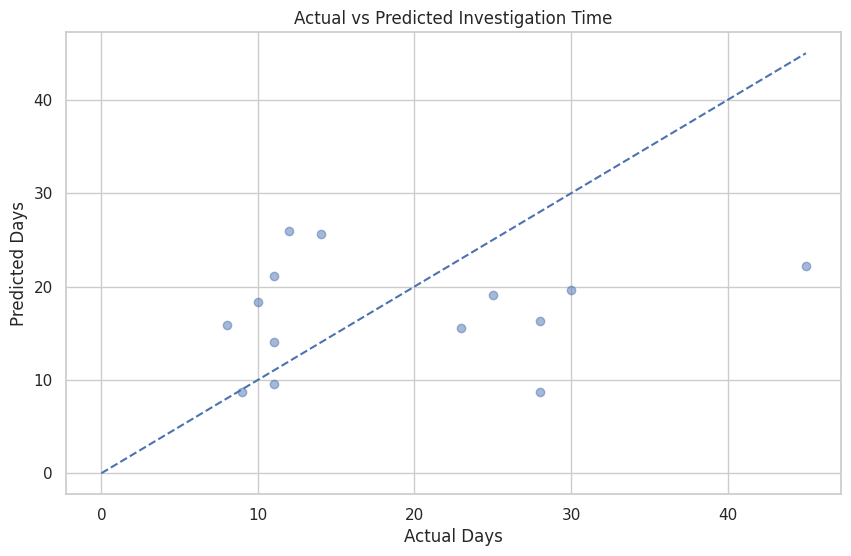

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)

max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.title("Actual vs Predicted Investigation Time")
plt.xlabel("Actual Days")
plt.ylabel("Predicted Days")

plt.show()

**Residual Analysis**

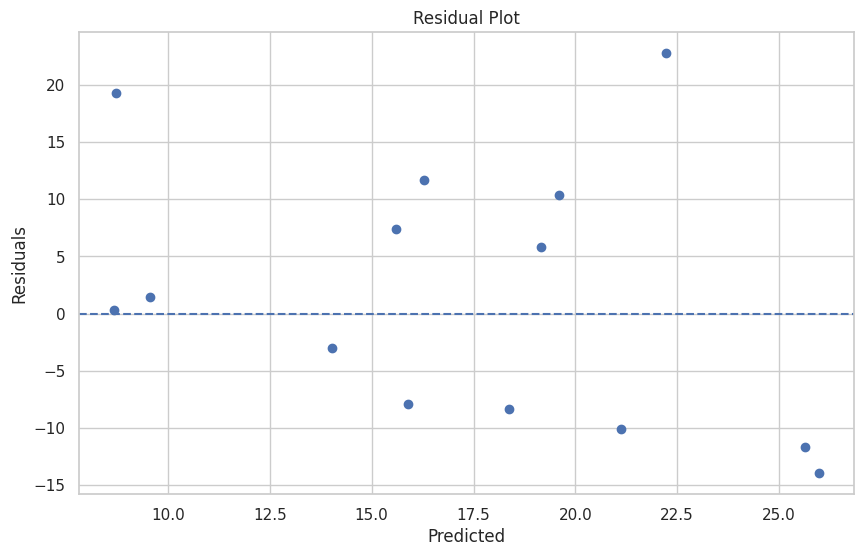

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.show()

**Feature Importance**

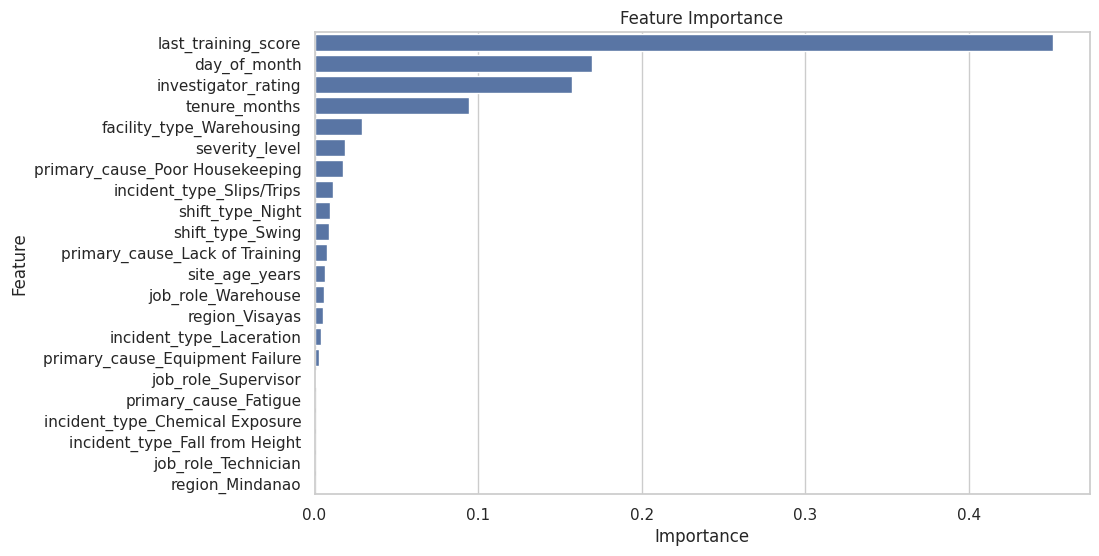

In [ ]:
cat_encoder = ml_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_cat_cols)

importances = ml_pipeline.named_steps['regressor'].regressor_.feature_importances_

feat_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

sns.barplot(data=feat_df, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()